# IT5006 - EDA starter
## SmartCommerce Data Exploration

**Duration:** ~60 minutes  
**Prerequisites:** Lab 1.0 (Python/PyTorch Refresher)  
**Environment:** Google Colab (recommended) or local Jupyter

---

### 🎯 Learning Objectives

This mini lab is for you to:

1. Load and understand the **Olist e-commerce dataset** schema
2. **Merge multiple tables** using relational keys (order_id, customer_id, product_id)
3. Compute foundational **business KPIs** (Revenue, AOV, Repeat Rate, On-Time Delivery)
4. Create basic **visualizations** to understand data distributions
5. Document the data assets available for downstream analytics

---

### 📊 About the Dataset

**Olist** is a Brazilian e-commerce platform. The dataset contains ~100K orders from 2016-2018 across 9 interconnected tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `orders` | Order metadata & timestamps | order_id, customer_id, status, timestamps |
| `order_items` | Line items per order | order_id, product_id, price, freight |
| `customers` | Customer location | customer_id, city, state |
| `products` | Product catalog | product_id, category, dimensions |
| `sellers` | Seller location | seller_id, city, state |
| `payments` | Payment details | order_id, payment_type, value |
| `reviews` | Customer feedback | order_id, score, comment |
| `geolocation` | Zip code coordinates | zip_code, lat, lng |
| `category_translation` | Portuguese → English | category names |

> 💡 **SmartCommerce** is our fictional brand name for this e-commerce case study throughout the course.


---

## 1. Environment Setup & Data Loading


In [1]:
# Google Colab users: mount Drive in the data path configuration cell below.

In [2]:
# Install dependencies (uncomment if running in Colab)
# !pip install -q pandas numpy matplotlib seaborn plotly

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


mkdir -p failed for path /Users/joshualum/.matplotlib: [Errno 1] Operation not permitted: '/Users/joshualum/.matplotlib'


Matplotlib created a temporary cache directory at /var/folders/lh/h9px96k96s33hykt549wrwv00000gn/T/matplotlib-0wn2h5po because there was an issue with the default path (/Users/joshualum/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.6
numpy: 2.5.3


In [3]:
# === DATA PATH CONFIGURATION ===
# Local Jupyter: find the repository data/ folder from either launch location.
from pathlib import Path
LOCAL_DATA_DIR = next(
    (root / "data" for root in (Path.cwd(), *Path.cwd().parents)
     if (root / "data" / "olist_orders_dataset.csv").is_file()),
    None,
)
if LOCAL_DATA_DIR is not None:
    DATA_DIR = str(LOCAL_DATA_DIR)
else:
    # Google Colab example: adjust this Drive path to your own Olist folder.
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/2026_work/IS5126/Olist"

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Olist data directory not found: {DATA_DIR}")
print(f"Data directory found: {DATA_DIR}")

Data directory found: /Users/joshualum/Documents/VSCode/IT5006_Grp_6/data


In [4]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols


Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


---

## 2. Schema Exploration

Let's understand each table's structure and relationships.


In [5]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
        })
    return pd.DataFrame(summary)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,13.62,"order_id, customer_id, order_status, order_pur..."
1,order_items,"112,650",7,17.12,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,11.57,"customer_id, customer_unique_id, customer_zip_..."
3,products,"32,951",9,3.91,"product_id, product_category_name, product_nam..."
4,sellers,"3,095",4,0.24,"seller_id, seller_zip_code_prefix, seller_city..."
5,payments,"103,886",5,8.50,"order_id, payment_sequential, payment_type, pa..."
6,reviews,"99,224",7,14.94,"review_id, order_id, review_score, review_comm..."
7,geolocation,"1,000,163",5,52.56,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,71,2,0.00,"product_category_name, product_category_name_e..."


### 2.1 Orders Table (Core Transaction Log)


In [6]:
# Orders - the central fact table
orders = olist['orders']
print("ORDERS TABLE")
print("=" * 50)
print(f"Shape: {orders.shape}")
print(f"\nColumn types:\n{orders.dtypes}")
print(f"\nOrder status distribution:\n{orders['order_status'].value_counts()}")
orders.head(3)

ORDERS TABLE
Shape: (99441, 8)

Column types:
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


### 2.2 Order Items Table (Line-Level Details)


In [7]:
# Order Items - contains price and freight
order_items = olist['order_items']
print("ORDER ITEMS TABLE")
print("=" * 50)
print(f"Shape: {order_items.shape}")
print(f"\nPrice statistics:")
print(order_items[['price', 'freight_value']].describe())
order_items.head(3)

ORDER ITEMS TABLE
Shape: (112650, 7)

Price statistics:
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


### 2.3 Products Table (Catalog)


In [8]:
# Products with category translation
products = olist['products'].merge(
    olist['category_translation'],
    on='product_category_name',
    how='left'
)
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

print("PRODUCTS TABLE (with English categories)")
print("=" * 50)
print(f"Shape: {products.shape}")
print(f"\nTop 10 categories:")
print(products['product_category_name_english'].value_counts().head(10))
products.head(3)

PRODUCTS TABLE (with English categories)
Shape: (32951, 10)

Top 10 categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure


### 2.4 Customers Table (Geography)


In [9]:
# Customers
customers = olist['customers']
print("CUSTOMERS TABLE")
print("=" * 50)
print(f"Shape: {customers.shape}")
print(f"Unique customers: {customers['customer_unique_id'].nunique():,}")
print(f"\nTop 10 states:")
print(customers['customer_state'].value_counts().head(10))
customers.head(3)

CUSTOMERS TABLE
Shape: (99441, 5)
Unique customers: 96,096

Top 10 states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### 2.5 Reviews Table (Customer Feedback)


In [10]:
# Reviews
reviews = olist['reviews']
print("REVIEWS TABLE")
print("=" * 50)
print(f"Shape: {reviews.shape}")
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nReviews with comments: {reviews['review_comment_message'].notna().sum():,} ({reviews['review_comment_message'].notna().mean():.1%})")
reviews.head(3)

REVIEWS TABLE
Shape: (99224, 7)

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Reviews with comments: 40,977 (41.3%)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


---

## 3. Merging Tables (Building the Analysis Dataset)

The Olist tables are **relational** — they connect via shared keys. Let's build a consolidated dataset for analysis.

```
orders ←→ order_items ←→ products
   ↓           ↓
customers   sellers
   ↓
reviews
```


In [11]:
# Build consolidated analysis dataset
# Step 1: Start with order_items (line-level)
df = olist['order_items'].copy()
print(f"Step 1 - order_items: {df.shape}")

# Step 2: Add product details
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id',
    how='left'
)
print(f"Step 2 - + products: {df.shape}")

# Step 3: Add order details
df = df.merge(
    olist['orders'][['order_id', 'customer_id', 'order_status',
                     'order_purchase_timestamp', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']],
    on='order_id',
    how='left'
)
print(f"Step 3 - + orders: {df.shape}")

# Step 4: Add customer details
df = df.merge(
    olist['customers'][['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)
print(f"Step 4 - + customers: {df.shape}")

# Step 5: Add seller details
df = df.merge(
    olist['sellers'][['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"Step 5 - + sellers: {df.shape}")

print(f"\n✅ Final consolidated dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Step 1 - order_items: (112650, 7)
Step 2 - + products: (112650, 9)
Step 3 - + orders: (112650, 14)


Step 4 - + customers: (112650, 16)
Step 5 - + sellers: (112650, 17)

✅ Final consolidated dataset: 112,650 rows × 17 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,RJ,campos dos goytacazes,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,SP,varzea paulista,PR


In [12]:
# Add derived columns for analysis
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Delivery metrics
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_on_time'] = (df['order_delivered_customer_date'].dt.normalize() <= df['order_estimated_delivery_date'].dt.normalize())

# Revenue per item
df['item_revenue'] = df['price'] + df['freight_value']

print("Added derived columns:")
print(df[['order_id', 'year_month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue']].head())

Added derived columns:


                           order_id year_month day_of_week  delivery_days  \
0  00010242fe8c5a6d1ba2dd792cb16214    2017-09   Wednesday           7.00   
1  00018f77f2f0320c557190d7a144bdd3    2017-04   Wednesday          16.00   
2  000229ec398224ef6ca0657da4fc703e    2018-01      Sunday           7.00   
3  00024acbcdf0a6daa1e931b038114c75    2018-08   Wednesday           6.00   
4  00042b26cf59d7ce69dfabb4e55b4fd9    2017-02    Saturday          25.00   

   is_on_time  item_revenue  
0        True         72.19  
1        True        259.83  
2        True        216.87  
3        True         25.78  
4        True        218.04  


---

## 4. Business KPIs Computation

Let's compute the key metrics that any e-commerce business tracks.


### 4.1 Overall Business Metrics


In [13]:
# Core business metrics
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_revenue = df['price'].sum()  # Product revenue (excluding freight)
total_revenue_with_freight = df['item_revenue'].sum()
total_products_sold = len(df)

# Date range
date_range = f"{df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}"

print("=" * 60)
print("SMARTCOMMERCE BUSINESS OVERVIEW")
print("=" * 60)
print(f"Data Period:        {date_range}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Customers:    {total_customers:,}")
print(f"Products Sold:      {total_products_sold:,}")
print(f"Total Revenue:      R$ {total_revenue:,.2f}")
print(f"Revenue + Freight:  R$ {total_revenue_with_freight:,.2f}")
print("=" * 60)

SMARTCOMMERCE BUSINESS OVERVIEW
Data Period:        2016-09-04 to 2018-09-03
Total Orders:       98,666
Total Customers:    98,666
Products Sold:      112,650
Total Revenue:      R$ 13,591,643.70
Revenue + Freight:  R$ 15,843,553.24


### 4.2 Average Order Value (AOV)


In [14]:
# Calculate AOV (Average Order Value)
order_totals = df.groupby('order_id')['price'].sum()
AOV = order_totals.mean()
AOV_median = order_totals.median()

print("AVERAGE ORDER VALUE (AOV)")
print("-" * 40)
print(f"Mean AOV:   R$ {AOV:.2f}")
print(f"Median AOV: R$ {AOV_median:.2f}")
print(f"Min Order:  R$ {order_totals.min():.2f}")
print(f"Max Order:  R$ {order_totals.max():.2f}")

AVERAGE ORDER VALUE (AOV)
----------------------------------------
Mean AOV:   R$ 137.75
Median AOV: R$ 86.90
Min Order:  R$ 0.85
Max Order:  R$ 13440.00


### 4.3 Customer Repeat Rate


In [15]:
# Repeat rate: customers who placed more than 1 order
# Note: customer_id is per-order, customer_unique_id is the true customer identifier
customer_orders = olist['orders'].merge(
    olist['customers'][['customer_id', 'customer_unique_id']],
    on='customer_id'
)
orders_per_customer = customer_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
total_unique_customers = len(orders_per_customer)
repeat_rate = repeat_customers / total_unique_customers

print("CUSTOMER REPEAT RATE")
print("-" * 40)
print(f"Unique Customers:    {total_unique_customers:,}")
print(f"Repeat Customers:    {repeat_customers:,}")
print(f"Repeat Rate:         {repeat_rate:.2%}")
print(f"\nOrders per customer distribution:")
print(orders_per_customer.value_counts().sort_index().head(10))

CUSTOMER REPEAT RATE
----------------------------------------
Unique Customers:    96,096
Repeat Customers:    2,997
Repeat Rate:         3.12%

Orders per customer distribution:
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


### 4.4 Delivery Performance


In [16]:
# Delivery metrics (only for delivered orders)
delivered = df[df['order_status'] == 'delivered'].copy()

avg_delivery_days = delivered['delivery_days'].mean()
median_delivery_days = delivered['delivery_days'].median()
on_time_rate = delivered['is_on_time'].mean()

print("DELIVERY PERFORMANCE")
print("-" * 40)
print(f"Delivered Orders:     {delivered['order_id'].nunique():,}")
print(f"Avg Delivery Days:    {avg_delivery_days:.1f} days")
print(f"Median Delivery Days: {median_delivery_days:.1f} days")
print(f"On-Time Rate:         {on_time_rate:.1%}")

DELIVERY PERFORMANCE
----------------------------------------
Delivered Orders:     96,478
Avg Delivery Days:    12.0 days
Median Delivery Days: 10.0 days
On-Time Rate:         93.4%


### 4.5 Customer Satisfaction (Review Scores)


In [17]:
# Review metrics
reviews = olist['reviews']
avg_score = reviews['review_score'].mean()
score_distribution = reviews['review_score'].value_counts(normalize=True).sort_index()

# NPS proxy: % 5-star minus % 1-2 star
promoters = (reviews['review_score'] == 5).mean()
detractors = (reviews['review_score'] <= 2).mean()
nps_proxy = (promoters - detractors) * 100

print("CUSTOMER SATISFACTION")
print("-" * 40)
print(f"Average Review Score: {avg_score:.2f} / 5.0")
print(f"NPS Proxy Score:      {nps_proxy:.1f}")
print(f"\nScore Distribution:")
for score, pct in score_distribution.items():
    bar = "█" * int(pct * 30)
    print(f"  {score}★: {bar} {pct:.1%}")

CUSTOMER SATISFACTION
----------------------------------------
Average Review Score: 4.09 / 5.0
NPS Proxy Score:      43.1

Score Distribution:
  1★: ███ 11.5%
  2★:  3.2%
  3★: ██ 8.2%
  4★: █████ 19.3%
  5★: █████████████████ 57.8%


### 4.6 KPI Summary Dashboard


In [18]:
# Consolidated KPI Summary
kpi_summary = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Orders', 'Unique Customers', 'AOV',
            'Repeat Rate', 'On-Time Delivery', 'Avg Review Score'],
    'Value': [f"R$ {total_revenue:,.0f}", f"{total_orders:,}", f"{total_unique_customers:,}",
              f"R$ {AOV:.2f}", f"{repeat_rate:.1%}", f"{on_time_rate:.1%}", f"{avg_score:.2f}"],
    'Benchmark': ['—', '—', '—', 'R$ 100-200', '20-30%', '>90%', '>4.0']
})

print("\n" + "=" * 60)
print("📊 SMARTCOMMERCE KPI DASHBOARD")
print("=" * 60)
print(kpi_summary.to_string(index=False))
print("=" * 60)


📊 SMARTCOMMERCE KPI DASHBOARD
             KPI         Value  Benchmark
   Total Revenue R$ 13,591,644          —
    Total Orders        98,666          —
Unique Customers        96,096          —
             AOV     R$ 137.75 R$ 100-200
     Repeat Rate          3.1%     20-30%
On-Time Delivery         93.4%       >90%
Avg Review Score          4.09       >4.0


---

## 5. Basic Visualizations

Let's create visualizations to understand the data distributions.


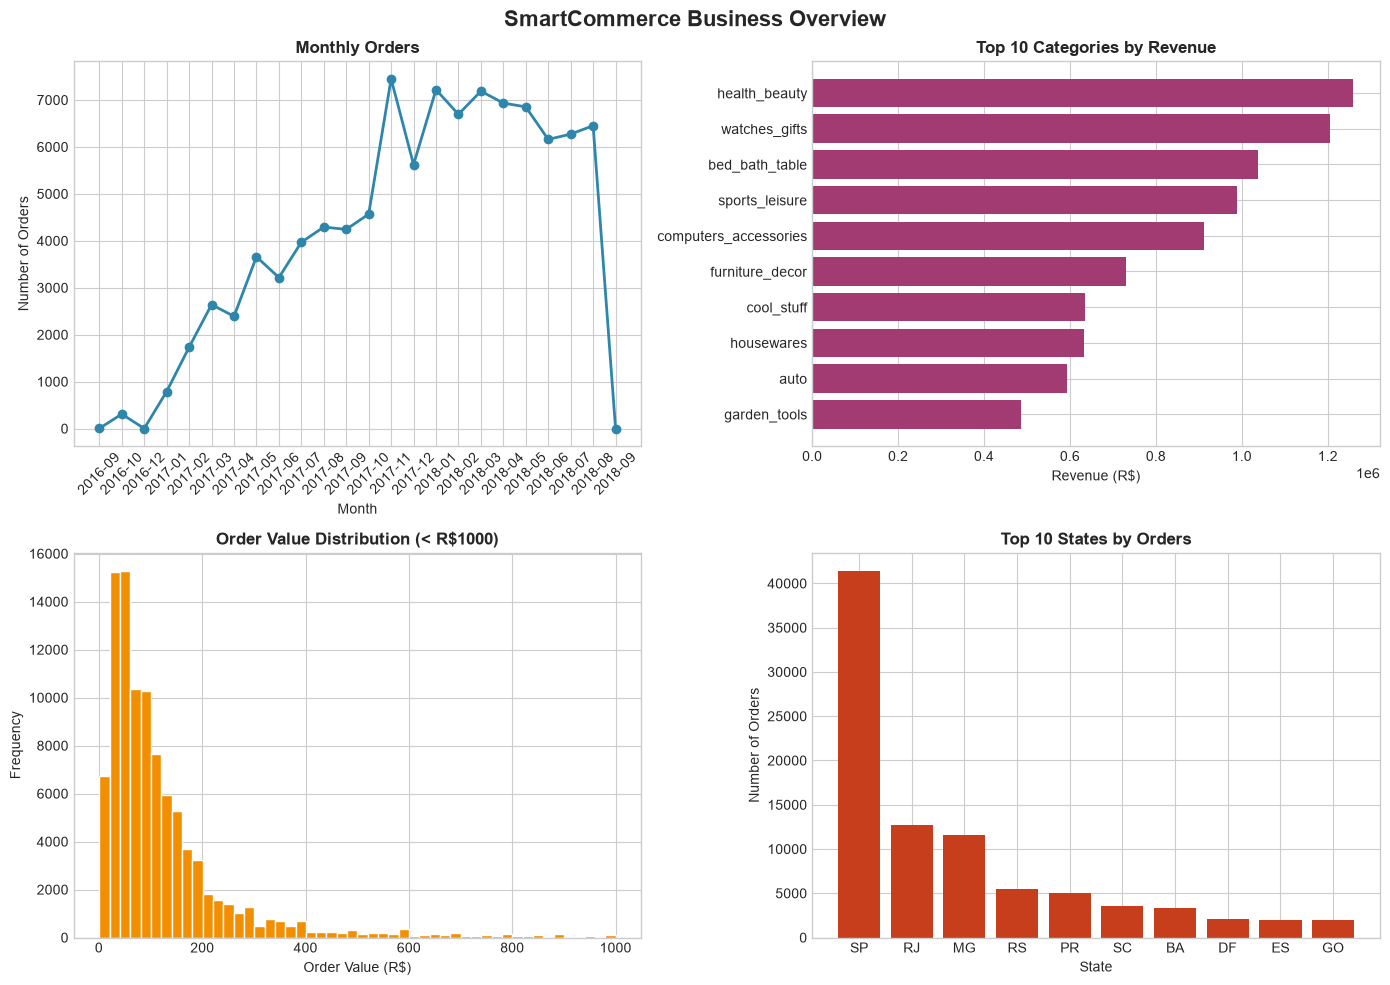

In [19]:
# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig_color = '#f8f9fa'

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartCommerce Business Overview', fontsize=16, fontweight='bold')

# 1. Orders over time
monthly_orders = df.groupby('year_month')['order_id'].nunique()
axes[0, 0].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].set_title('Monthly Orders', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue by category (top 10)
cat_revenue = df.groupby('product_category_name_english')['price'].sum().nlargest(10)
axes[0, 1].barh(cat_revenue.index, cat_revenue.values, color='#A23B72')
axes[0, 1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0, 1].set_xlabel('Revenue (R$)')
axes[0, 1].invert_yaxis()

# 3. Order value distribution
order_values = df.groupby('order_id')['price'].sum()
axes[1, 0].hist(order_values[order_values < 1000], bins=50, color='#F18F01', edgecolor='white')
axes[1, 0].set_title('Order Value Distribution (< R$1000)', fontweight='bold')
axes[1, 0].set_xlabel('Order Value (R$)')
axes[1, 0].set_ylabel('Frequency')

# 4. Orders by state (top 10)
state_orders = df.groupby('customer_state')['order_id'].nunique().nlargest(10)
axes[1, 1].bar(state_orders.index, state_orders.values, color='#C73E1D')
axes[1, 1].set_title('Top 10 States by Orders', fontweight='bold')
axes[1, 1].set_xlabel('State')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

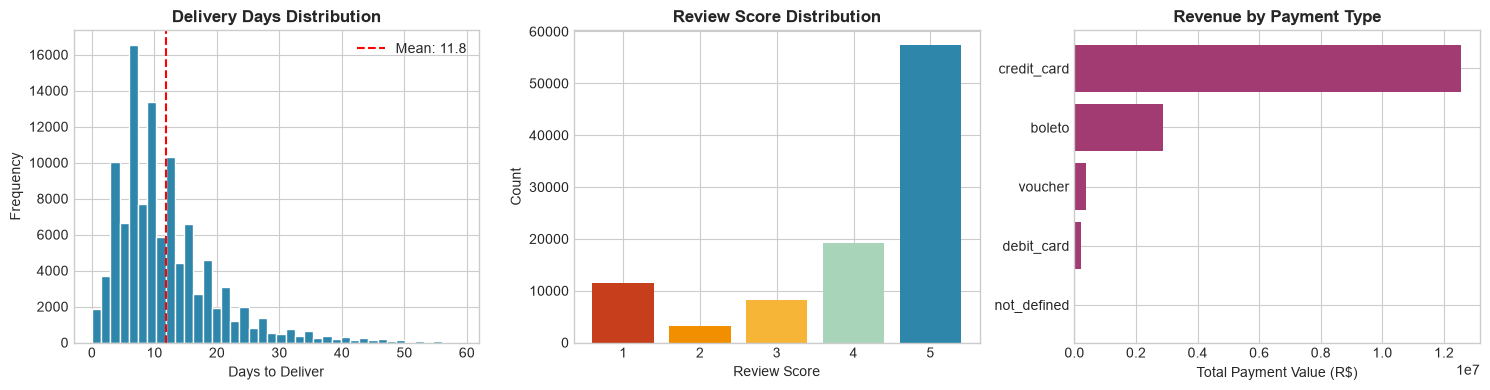

In [20]:
# Delivery and Review Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Delivery days distribution
delivered_data = df[df['delivery_days'].notna() & (df['delivery_days'] < 60)]
axes[0].hist(delivered_data['delivery_days'], bins=40, color='#2E86AB', edgecolor='white')
axes[0].axvline(delivered_data['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {delivered_data['delivery_days'].mean():.1f}")
axes[0].set_title('Delivery Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days to Deliver')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review score distribution
score_counts = olist['reviews']['review_score'].value_counts().sort_index()
colors = ['#C73E1D', '#F18F01', '#F7B538', '#A8D5BA', '#2E86AB']
axes[1].bar(score_counts.index, score_counts.values, color=colors)
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

# 3. Payment type distribution
payment_dist = olist['payments'].groupby('payment_type')['payment_value'].sum().sort_values(ascending=True)
axes[2].barh(payment_dist.index, payment_dist.values, color='#A23B72')
axes[2].set_title('Revenue by Payment Type', fontweight='bold')
axes[2].set_xlabel('Total Payment Value (R$)')

plt.tight_layout()
plt.show()

---

## 6. Save Prepared Dataset

Save the consolidated dataset for use in future labs.


In [ ]:
# Save consolidated dataset for future labs
output_path = os.path.join(DATA_DIR, "smartcommerce_consolidated_rebuilt.csv")
df.to_csv(output_path, index=False)
print(f"✅ Saved consolidated dataset to: {output_path}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size: {os.path.getsize(output_path) / 1e6:.2f} MB")

---

## ✅ Lab Summary

### What you finished!

1. **Data Loading**: Loaded 9 interconnected Olist tables
2. **Schema Understanding**: Identified key columns and relationships
3. **Table Merging**: Built a consolidated analysis dataset using `merge()`
4. **KPI Computation**: Calculated core e-commerce metrics:
   - Revenue & AOV
   - Repeat Rate
   - Delivery Performance
   - Customer Satisfaction


---

## 📝 Exercise (Optional)

1. Calculate the **month-over-month growth rate** for orders
2. Find the **top 5 sellers by revenue**
3. Identify which **product category has the worst delivery performance**
